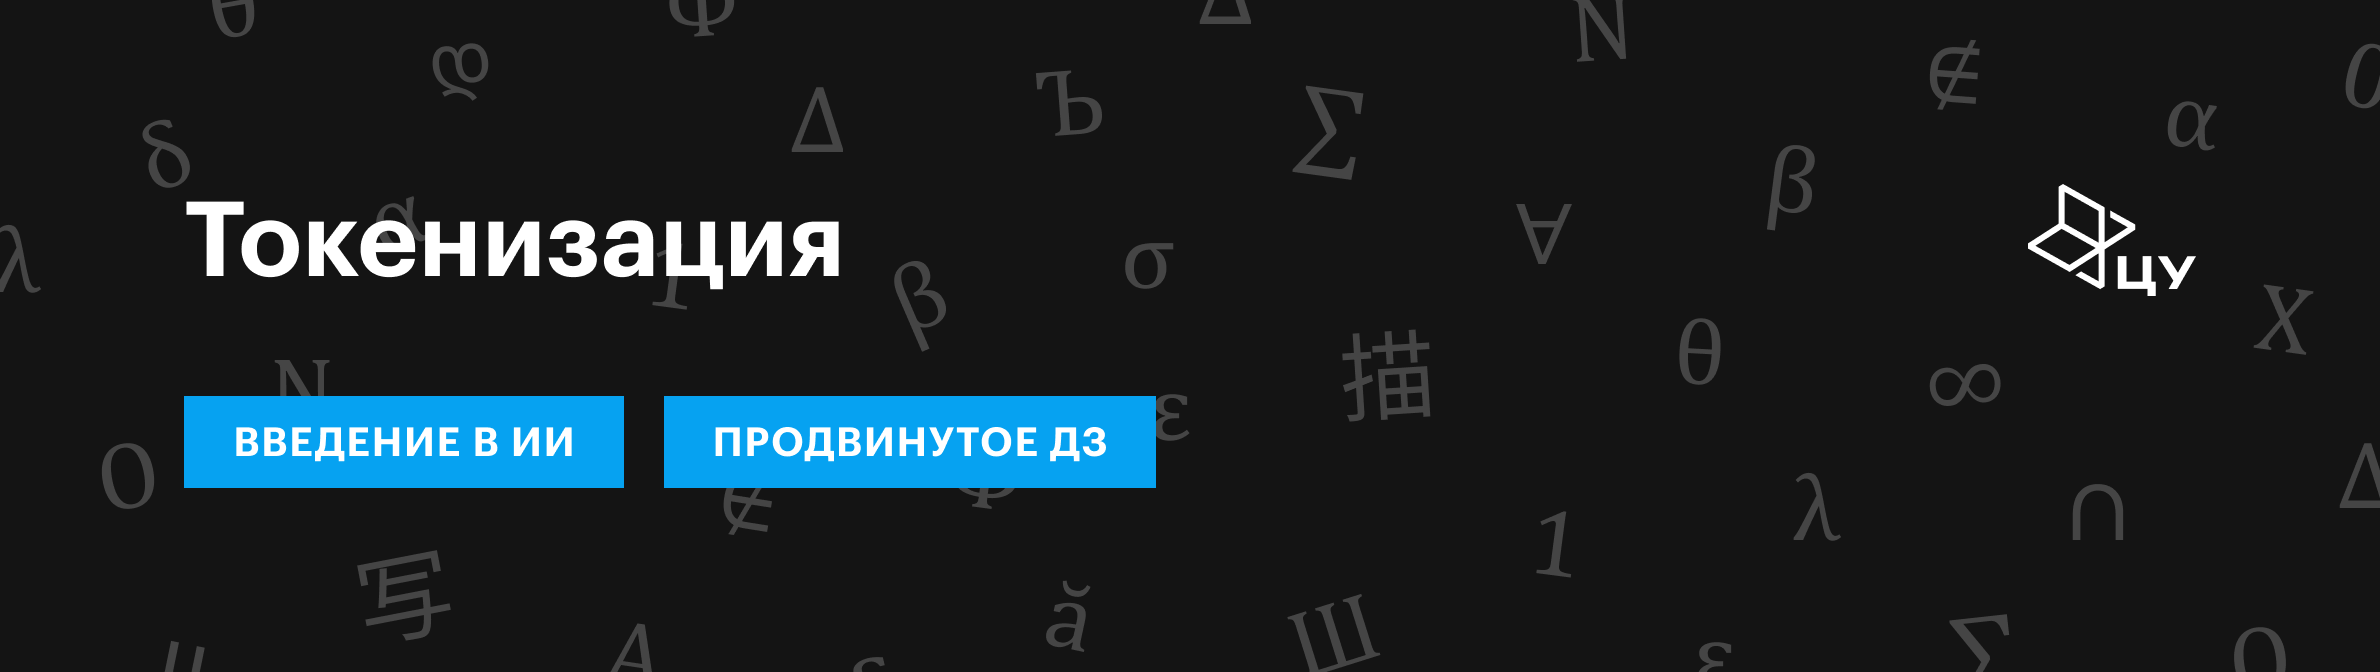

# Домашнее задание по теме «Токенизация»

Тебе предстоит реализовать классификатор русскоязычных постов в Twitter (сейчас соцсеть X) из датасета RuTweetCorp.

Для этого нужно использовать простую логистическую регрессию. Как тебе известно, с текстом она работать не умеет, поэтому тебе необходимо предобработать текст, а затем для обработанных текстов создать векторные представления TF-IDF. На них уже и будет обучаться основная модель.


>### Правила домашнего задания
>1. Нельзя удалять существующие ячейки кода.
>
>2. Можно добавлять и дописывать свои ячейки.
>
>3. Место, куда тебе нужно написать код, помечается комментарием.
>
> 4. Ответ без кода, который подтвердит твоё решение, не засчитывается. Исключение — задачи и вопросы, где код не требуется и нужно сделать вывод из известных данных.
>
 > 5. Код должен быть работоспособным. У проверяющих должна быть возможность воспроизвести все полученные результаты.

## Загрузка и первичная обработка данных

Загружаем датасет RuTweetCorp и приводим к нужному нам виду. В нём посты разделены на оскорбительные (negative) и те, где оскорбления отсутствуют (positive).

Датасет доступен в [Kaggle](https://www.kaggle.com/datasets/maximsuvorov/rutweetcorp).

Источник датасета: Рубцов Ю. Автоматическое построение и анализ корпуса коротких текстов (постов микроблогов) для задачи разработки и тренировки тонового классификатора // Инженерия знаний и технологии семантического веба. — 2012. — Т. 1. — С. 109–116.

In [1]:
# Загружаем файлы нашего датасета с помощью
!gdown 1cfhbBTWKEp4bfgHfmkvnqP7ClkNVA_LP
# И распаковываем его
!unzip /content/data.zip

Downloading...
From: https://drive.google.com/uc?id=1cfhbBTWKEp4bfgHfmkvnqP7ClkNVA_LP
To: /content/data.zip
100% 18.7M/18.7M [00:01<00:00, 13.8MB/s]
Archive:  /content/data.zip
  inflating: data/negative.csv       
  inflating: data/positive.csv       


In [2]:
import gc # Пригодится, чтобы удалить ненужные таблички
import pandas as pd
import numpy as np

In [3]:
# Считываем данные. Положительные и негативные комментарии лежат в разных файлах. Далее мы их объединим
pos = pd.read_csv('data/positive.csv', index_col=0)
neg = pd.read_csv('data/negative.csv', index_col=0)

In [4]:
# Посмотрим на датасет
pos

,tdate,tname,ttext,ttype,trep,trtw,tfav,tstcount,tfoll,tfrien,listcount
id,,,,,,,,,,,
408906692374446080,1386325927,pleease_shut_up,"@first_timee хоть я и школота, но поверь, у на...",1,0,0,0,7569,62,61,0
408906692693221377,1386325927,alinakirpicheva,"Да, все-таки он немного похож на него. Но мой ...",1,0,0,0,11825,59,31,2
408906695083954177,1386325927,EvgeshaRe,RT @KatiaCheh: Ну ты идиотка) я испугалась за ...,1,0,1,0,1273,26,27,0
408906695356973056,1386325927,ikonnikova_21,"RT @digger2912: ""Кто то в углу сидит и погибае...",1,0,1,0,1549,19,17,0
408906761416867842,1386325943,JumpyAlex,@irina_dyshkant Вот что значит страшилка :D\nН...,1,0,0,0,597,16,23,1
...,...,...,...,...,...,...,...,...,...,...,...
411368729235054592,1386912922,diminlisenok,"Спала в родительском доме, на своей кровати......",1,0,0,0,1497,56,34,2
411368729424187392,1386912922,qilepocagotu,RT @jebesilofyt: Эх... Мы немного решили сокра...,1,0,1,0,692,225,210,0
411368796537257984,1386912938,DennyChooo,"Что происходит со мной, когда в эфире #proacti...",1,0,0,0,4905,448,193,13


Помимо текста (`ttext`) и метки класса (`ttype`), в датасете присутствует и другая информация о сообщении, например, количество просмотров или ответов на сообщение.

Эта информация может оказаться важной, но необходимо сосредоточиться на работе с текстом, поэтому исключим ненужные колонки.

In [5]:
pos.drop(columns=['tdate', 'tname', 'trep', 'trtw', 'tfav', 'tstcount', 'tfoll', 'tfrien', 'listcount'], inplace=True)
neg.drop(columns=['tdate', 'tname', 'trep', 'trtw', 'tfav', 'tstcount', 'tfoll', 'tfrien', 'listcount'], inplace=True)

In [6]:
pos

,ttext,ttype
id,,
408906692374446080,"@first_timee хоть я и школота, но поверь, у на...",1
408906692693221377,"Да, все-таки он немного похож на него. Но мой ...",1
408906695083954177,RT @KatiaCheh: Ну ты идиотка) я испугалась за ...,1
408906695356973056,"RT @digger2912: ""Кто то в углу сидит и погибае...",1
408906761416867842,@irina_dyshkant Вот что значит страшилка :D\nН...,1
...,...,...
411368729235054592,"Спала в родительском доме, на своей кровати......",1
411368729424187392,RT @jebesilofyt: Эх... Мы немного решили сокра...,1
411368796537257984,"Что происходит со мной, когда в эфире #proacti...",1


In [8]:
# Объединим таблички с положительными и негативными комментариями в одну
df = pd.concat([pos, neg])
del pos, neg
gc.collect()

NameError: name 'pos' is not defined

In [9]:
# Вот такой датасет получился
df

,ttext,ttype
id,,
408906692374446080,"@first_timee хоть я и школота, но поверь, у на...",1
408906692693221377,"Да, все-таки он немного похож на него. Но мой ...",1
408906695083954177,RT @KatiaCheh: Ну ты идиотка) я испугалась за ...,1
408906695356973056,"RT @digger2912: ""Кто то в углу сидит и погибае...",1
408906761416867842,@irina_dyshkant Вот что значит страшилка :D\nН...,1
...,...,...
425138243257253888,Но не каждый хочет что то исправлять:( http://...,-1
425138339503943682,скучаю так :-( только @taaannyaaa вправляет мо...,-1
425138437684215808,"Вот и в школу, в говно это идти уже надо(",-1


In [10]:
# Заменим класс −1 на 0, так как именно с таким обозначением работают модели машинного обучения классификации
df['ttype'] = df['ttype'].mask(df['ttype']<0, 0)

Теперь необходимо разделить выборку на обучающую, валидационную и тестовую, для этого поможет `train_test_split`.

В коде ниже указаны называния этих выборок — именно с ними тебе и предстоит работать.

In [11]:
from sklearn.model_selection import train_test_split

# Разбиваем выборку на обучающую и валидационно-тестовую
df_train, df_val_test = train_test_split(df, train_size=0.7, random_state=42, shuffle=True, stratify=df['ttype'])
# Разбиваем на валидационную и тестовую
df_val, df_test = train_test_split(df_val_test, train_size=0.5, random_state=42, shuffle=True, stratify=df_val_test['ttype'])
# Удаляем всё ненужное
del df, df_val_test
gc.collect()

0

In [12]:
df_train

,ttext,ttype
id,,
411132412534734848,RT @wubirucifiz: Клёво так сразу детство вспом...,1
410799527432441857,"Завтра сочинение по русскому на тему ""Письмо-р...",1
416428363931475970,@Leriaaaa да.. А еще когда у тебя в жизни почт...,0
410471481194582016,Нати с сыночком:))) ❤❤❤ #oreiro http://t.co/DB...,1
422957482890493952,RT @Sanya_Berezina: Я только чашку воды выпила...,0
...,...,...
422394926631243776,Не ну норм? У меня в районе 8 автошкол?? Всего...,0
410798919703359489,"Ух ты, Глинка уже будет работать в эти выходны...",1
418291069650866176,А я вот второй год подряд забываю про желание:(,0


Теперь можно приступать к решению домашнего задания!

## TF-IDF
Чтобы решить задачу классификации, сначала необходимо представить тексты в виде чисел. Самый простой способ:
- посчитать вхождения различных слов в каждый текст;
- представить данные в формате «количество текстов на количество наблюдений»;
- перевзвесить результаты в зависимости от частотности слов внутри каждого текста и в датасете в целом — то есть применить метод векторизации TF-IDF.

Но, как обсуждалось на лекции, с сырыми текстами так лучше не делать, так как это увеличивает словарь уникальных слов. Размерность данных станет огромной, поэтому необходимо сделать следующее.

1) Привести все слова к нижнему регистру.

2) Удалить знаки препинания, различные символы и числительные.

3) Удалить стоп-слова (предлоги, союзы, частицы).

4) Лемматизировать слова.

5) Удалить редко встречающиеся слова, так как это могут быть просто опечатки.


## Задание 1. Приведение слов к нижнему регистру [0,5 балла]
Реализуй функцию, которая принимает датасет на вход и приводит весь текст к нижнему регистру.

Примени функцию для всех подвыборок.

In [16]:
def to_lower(df):
  return df['ttext'].str.lower()

df_train['ttext'] = to_lower(df_train)# Напиши код здесь
df_val['ttext'] = to_lower(df_val)# Напиши код здесь
df_test['ttext'] = to_lower(df_test)# Напиши код здесь

In [17]:
df_train

,ttext,ttype
id,,
411132412534734848,rt @wubirucifiz: клёво так сразу детство вспом...,1
410799527432441857,"завтра сочинение по русскому на тему ""письмо-р...",1
416428363931475970,@leriaaaa да.. а еще когда у тебя в жизни почт...,0
410471481194582016,нати с сыночком:))) ❤❤❤ #oreiro http://t.co/db...,1
422957482890493952,rt @sanya_berezina: я только чашку воды выпила...,0
...,...,...
422394926631243776,не ну норм? у меня в районе 8 автошкол?? всего...,0
410798919703359489,"ух ты, глинка уже будет работать в эти выходны...",1
418291069650866176,а я вот второй год подряд забываю про желание:(,0


## Задание 2. Удаление знаков препинания, числительных и спецсимволов [1 балл]

Напиши функцию для очистки текстов от малоинформативных символов — числительных, знаков препинания и служебных символов.

Возможны следующие служебные символы:
- \n — новая строка;
- \t — табуляция;
- \r — возврат курсора в начало строки (довольно редко, но может встречаться в текстах).

Выполнить задание можно с помощью встроенного в pandas [replace](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.replace.html) и несложных регулярных выражений (regex).

Если хочешь узнать о регулярных выражениях подробнее, есть неплохой короткий [гайд](https://coderpad.io/blog/development/the-complete-guide-to-regular-expressions-regex/).



Итак, напиши функцию, которая убирает из текста:
- служебные символы;
- знаки препинания;
- числительные.

Затем примени ко всем подвыборкам.

In [18]:
def regex_clean(df):
  return df['ttext'].str.replace(r'[\n\t\r]', ' ', regex=True) \
                      .str.replace(r'[^a-zA-Zа-яА-Я\s]', '', regex=True)# Напиши код здесь

df_train['ttext'] = regex_clean(df_train)
df_val['ttext'] = regex_clean(df_val)
df_test['ttext'] = regex_clean(df_test)

In [19]:
df_train

,ttext,ttype
id,,
411132412534734848,rt wubirucifiz клво так сразу детство вспомнил...,1
410799527432441857,завтра сочинение по русскому на тему письморец...,1
416428363931475970,leriaaaa да а еще когда у тебя в жизни почти т...,0
410471481194582016,нати с сыночком oreiro httptcodbyywmu,1
422957482890493952,rt sanyaberezina я только чашку воды выпила а ...,0
...,...,...
422394926631243776,не ну норм у меня в районе автошкол всего лиш...,0
410798919703359489,ух ты глинка уже будет работать в эти выходные,1
418291069650866176,а я вот второй год подряд забываю про желание,0


## Задание 3. Удаление стоп-слов [0,5 балла]

Теперь надо очистить тексты от стоп-слов. Это различные предлоги, союзы, местоимения, которые не содержат в себе много информации, но при этом довольно часто встречаются в текстах.

Стоп-слова для русского языка можно найти в библиотеке nltk. Импортируем её и определим стоп-слова.

In [20]:
# Импортируем пакет NLTK и подгружаем модуль stopwords
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Загружаем русские стоп-слова
s_words = set(stopwords.words('russian'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [21]:
s_words

{'а',
 'без',
 'более',
 'больше',
 'будет',
 'будто',
 'бы',
 'был',
 'была',
 'были',
 'было',
 'быть',
 'в',
 'вам',
 'вас',
 'вдруг',
 'ведь',
 'во',
 'вот',
 'впрочем',
 'все',
 'всегда',
 'всего',
 'всех',
 'всю',
 'вы',
 'где',
 'да',
 'даже',
 'два',
 'для',
 'до',
 'другой',
 'его',
 'ее',
 'ей',
 'ему',
 'если',
 'есть',
 'еще',
 'ж',
 'же',
 'за',
 'зачем',
 'здесь',
 'и',
 'из',
 'или',
 'им',
 'иногда',
 'их',
 'к',
 'как',
 'какая',
 'какой',
 'когда',
 'конечно',
 'кто',
 'куда',
 'ли',
 'лучше',
 'между',
 'меня',
 'мне',
 'много',
 'может',
 'можно',
 'мой',
 'моя',
 'мы',
 'на',
 'над',
 'надо',
 'наконец',
 'нас',
 'не',
 'него',
 'нее',
 'ней',
 'нельзя',
 'нет',
 'ни',
 'нибудь',
 'никогда',
 'ним',
 'них',
 'ничего',
 'но',
 'ну',
 'о',
 'об',
 'один',
 'он',
 'она',
 'они',
 'опять',
 'от',
 'перед',
 'по',
 'под',
 'после',
 'потом',
 'потому',
 'почти',
 'при',
 'про',
 'раз',
 'разве',
 'с',
 'сам',
 'свою',
 'себе',
 'себя',
 'сейчас',
 'со',
 'совсем',
 'так

Реализуй функцию, которая отфильтровывает стоп-слова из текстов.

Затем примени её к разным подвыборкам с помощью [apply](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.apply.html).

In [46]:
def remove_stopwords(s: str):
  return ' '.join([word for word in s.split() if word not in s_words])

# Применяем функцию к нашим данным
df_train['ttext'] = df_train['ttext'].apply(remove_stopwords)# Напиши код здесь
df_val['ttext'] = df_val['ttext'].apply(remove_stopwords)# Напиши код здесь
df_test['ttext'] = df_test['ttext'].apply(remove_stopwords)# Напиши код здесь

In [48]:
df_train

,ttext,ttype
id,,
411132412534734848,rt wubirucifiz клво сразу детство вспомнилполи...,1
410799527432441857,завтра сочинение русский тема письморецензия л...,1
416428363931475970,leriaaaa жизнь ситуация,0
410471481194582016,ната сыночек oreiro httptcodbyywmu,1
422957482890493952,rt sanyaberezina чашка вода выпивать хотеть ту...,0
...,...,...
422394926631243776,норма район автошкола лишь идти учиться,0
410798919703359489,ух глинка работать выходной,1
418291069650866176,второй год подряд забывать желание,0


## Задание 4. Лемматизация [1 балл]
Лемматизация — это процесс приведения слова к его начальной форме, а именно:
* к единственному числу,
* мужскому роду,
* инфинитиву (для глаголов).

Для лемматизации на русском языке существует два пакета: [pymystem3](https://pypi.org/project/pymystem3/) и [pymorphy2](https://pymorphy2.readthedocs.io/en/stable/).

Оба пакета довольно старые и не обновлялись давно, но при этом всё ещё рабочие. Ты можешь выбрать любой на своё усмотрение.

Итак, в этом задании тебе необходимо сделать следующее.
1. Выбрать лемматизатор.
2. Лемматизировать все тексты.
3. Ещё раз очистить от стоп-слов, потому что после лемматизации некоторые слова поменяют форму и станут стоп-словами.
4. Если используешь pymystem3 — удалить служебный символ '\n', который добавляется в конце лемматизированных текстов (не баг, а фича).




In [25]:
!pip install pymystem3

In [47]:
from pymystem3 import Mystem

m = Mystem()
# Инициализируй лемматизатор вне функции для лемматизации, чтобы не инциализировать его на каждый вызов, так как это долго

# Функция для лемматизации

def lemmatize(s: str):
    text = ''.join(m.lemmatize(s)).replace('\n', '').strip()
    return ' '.join([word for word in text.split() if word not in s_words])# Напиши код здесь

df_train['ttext'] = df_train['ttext'].apply(lemmatize)# Напиши код здесь
df_val['ttext'] = df_val['ttext'].apply(lemmatize)# Напиши код здесь
df_test['ttext'] = df_test['ttext'].apply(lemmatize)# Напиши код здесь

In [49]:
df_train

,ttext,ttype
id,,
411132412534734848,rt wubirucifiz клво сразу детство вспомнилполи...,1
410799527432441857,завтра сочинение русский тема письморецензия л...,1
416428363931475970,leriaaaa жизнь ситуация,0
410471481194582016,ната сыночек oreiro httptcodbyywmu,1
422957482890493952,rt sanyaberezina чашка вода выпивать хотеть ту...,0
...,...,...
422394926631243776,норма район автошкола лишь идти учиться,0
410798919703359489,ух глинка работать выходной,1
418291069650866176,второй год подряд забывать желание,0


## Задание 5. Получение TF-IDF-эмбеддингов и обучение логистической регрессии [7 баллов]

Теперь пора получить векторные представления текстов с помощью [TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html).

Обрати особое внимание на каждый аргумент в документации — их нужно будет подбирать, чтобы получить максимальное качество.

В этом задании тебе необходимо следующее.
1. Получить векторные представления текстов для обучающей и валидационной подвыборок. Подумай над тем, когда применять `fit_transform`, а когда просто `transform` — **[0,5 балла].**
2. Обучить на них логистическую регрессию — **[0,5 балла].**
3. Проверить результаты обучения по метрике [Accuracy](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html) на обучающей и валидационной выборках — **[1 балл]**.
4. Повторяя шаги 1–3, перебрать параметры для TF-IDF и улучшить итоговое качество — **[1 балл].**
5. Для лучшего варианта параметров для TF-IDF вычислить качество на тестовой выборке. Для максимального балла оно должно превзойти качество автора домашнего задания в 72,7% на валидации и 72,4% на тесте — **[до 4 баллов].**

Для подбора параметров ты можешь модифицировать данный код так, как захочешь.

In [52]:
# Импортируем TF-IDF, логистическую регрессию и Accuracy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

vectorizer = TfidfVectorizer()# Твои аргументы)

train_tfidf = vectorizer.fit_transform(df_train['ttext'])# Напиши код здесь
val_tfidf = vectorizer.transform(df_val['ttext'])# Напиши код здесь

# Учи со стандартными параметрами, подбирать можно только параметры TF-IDF
model_tfidf = LogisticRegression(max_iter=1000)

# Обучи модель и получи предсказания для валидационной и тестовой выборки
model_tfidf.fit(train_tfidf, df_train['ttype'])# Напиши код здесь)
train_pred_tfidf = model_tfidf.predict(train_tfidf)# Напиши код здесь)
val_pred_tfidf = model_tfidf.predict(val_tfidf)# Напиши код здесь)

# Получи оценку качества моделей
print(f'Train: {accuracy_score(train_pred_tfidf, df_train['ttype'])*100}%')
print(f'Val: {accuracy_score(val_pred_tfidf, df_val['ttype'])*100}%')

Train: 83.40250530598364%
Val: 73.34019103600295%


In [53]:
# Для выбранных гиперпараметров TF-IDF получи предсказание на test и оцени качество

test_tfidf = vectorizer.transform(df_test['ttext'])# Напиши код здесь
test_pred_tfidf = model_tfidf.predict(test_tfidf)# Напиши код здесь)

print(f'Test: {accuracy_score(test_pred_tfidf, df_test['ttype'])*100}%')

Test: 73.5202492211838%


Я вообще не дообучал модель, даже гиперпараметры не менял.
Я сначала забыл лемматизировать и я выбил скор лучше чем до этого, лол